<h1 align="center">Life Satisfaction Prediction using GDP per Capita</h1>

**Assignment Note**

This assignment is not intended to be a full project. It serves as a follow up to reinforce the
concepts we have covered in lecture so far. More comprehensive analyses and detailed
projects will be introduced as we progress further into the course.

---

#### 🤔📚 Learning Objectives

- Load and visualize real-world data.
- Train and compare regression models using Scikit-Learn.
- Interpret model outputs and discuss generalization.

---

### Imports

In [61]:
import pandas
import numpy as np
import matplotlib.pyplot as pyplot
import seaborn
from sklearn.linear_model import LinearRegression


### Part 1: Data Exploration and Visualization (20 marks)

**Q1 (5 marks)** Load the dataset lifesat.csv and display the first 5 rows.

In [62]:
dl = pandas.read_csv("./lifesat.csv")

dl.head()

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


**Q2 (5 marks)** Print basic info and summary statistics .

In [63]:
dl.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               27 non-null     str    
 1   GDP per capita (USD)  27 non-null     float64
 2   Life satisfaction     27 non-null     float64
dtypes: float64(2), str(1)
memory usage: 983.0 bytes


In [64]:
dl.describe()

,GDP per capita (USD),Life satisfaction
count,27.000000,27.000000
mean,41564.521771,6.566667
std,9631.452319,0.765607
min,26456.387938,5.400000
25%,33938.289305,5.900000
50%,41627.129269,6.800000
75%,49690.580269,7.300000
max,60235.728492,7.600000


**Q3 (10 marks)** Display a scatter plot for GDP per capita vs Life Satisfaction . Add labels, title, and discuss the observed relationship.

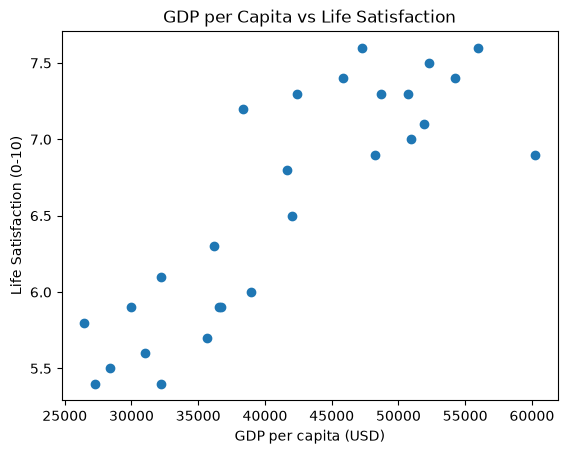

In [65]:
X = dl["GDP per capita (USD)"]
Y = dl["Life satisfaction"]
pyplot.scatter(X, Y)
pyplot.xlabel("GDP per capita (USD)")
pyplot.ylabel("Life Satisfaction (0-10)")
pyplot.title("GDP per Capita vs Life Satisfaction")
pyplot.show()

**Discuss the observed relationship:**

GDP per capita has a strong positive, roughly linear association with life satisfaction in this sample, but there are notable exceptions and signs of diminishing returns at high income. Income is an important factor, but it is not the only one.

### Part 2: Linear Regression Model (30 marks)

**Q4 (5 marks)** Extract input (X) and target (y). Print their shapes.

In [66]:
X = dl[["GDP per capita (USD)"]].values
y = dl[["Life satisfaction"]].values
print("Shape of X:", X.shape)   # (27, 1)
print("Shape of y:", y.shape)   # (27, 1)

Shape of X: (27, 1)
Shape of y: (27, 1)


**Q5 (10 marks)** Train a Linear Regression model & Display coefficient and intercept.

In [67]:
model = LinearRegression()
model.fit(X, y)
print("Coefficient (slope):", model.coef_[0][0])
print("Intercept:", model.intercept_[0])
print(f"Model: Life satisfaction = {model.intercept_[0]:.4f} "
      f"+ {model.coef_[0][0]:.4e} x GDP per capita")
print("R^2 score:", round(model.score(X, y), 4))

Coefficient (slope): 6.778899694341226e-05
Intercept: 3.7490494273769075
Model: Life satisfaction = 3.7490 + 6.7789e-05 x GDP per capita
R^2 score: 0.7273


**Q6 (10 marks)** Plot the predicted regression line from the model along with a scatter plot of the data.

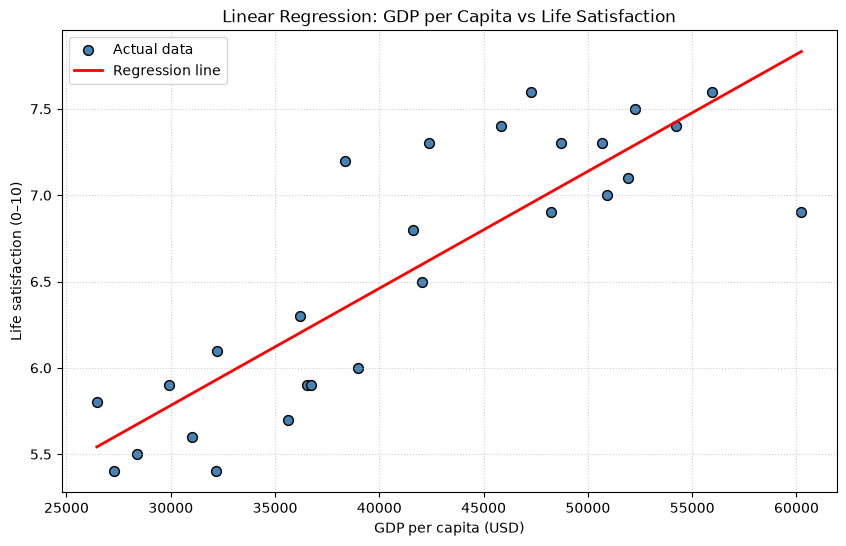

In [68]:
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
 
pyplot.figure(figsize=(10, 6))

pyplot.scatter(X, y, color="steelblue", edgecolor="black", s=50, label="Actual data")
pyplot.plot(X_line, y_line, color="red", linewidth=2, label="Regression line")

pyplot.xlabel("GDP per capita (USD)")
pyplot.ylabel("Life satisfaction (0–10)")
pyplot.title("Linear Regression: GDP per Capita vs Life Satisfaction")

pyplot.grid(True, linestyle=":", alpha=0.6)
pyplot.legend()

pyplot.show()

**Q7 (5 marks)** Predict Life Satisfaction for GDP = 37,655.2 USD. Comment on result.

In [69]:
X_new = [[37_655.2]]
y_new = model.predict(X_new)
print(f"Predicted life satisfaction for GDP = 37,655.2 USD: {y_new[0][0]:.2f}")

Predicted life satisfaction for GDP = 37,655.2 USD: 6.30


### Part 3: K-Nearest Neighbors Regression (25 marks)

**Q8 (5 marks)** Train a KNeighborsRegressor (n_neighbors=3).

In [70]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X, Y)   

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


**Q9 (10 marks)**
- Predict Life Satisfaction for GDP = 37,655.2 USD
- and compare with Linear Regression.

In [71]:
X_new = [[37_655.2]]
knn_pred = np.ravel(knn.predict(X_new))[0]
lin_pred = np.ravel(model.predict(X_new))[0]

print(knn_pred)
print(lin_pred)

6.333333333333333
6.3016576650804845


KNN averages the life satisfaction of the 3 countries closest in GDP:

Country     | GDP           | Life Satisfaction
------------|---------------|------------------
Israel      | $38,341       | 7.2
Lithuania   | $36,732	    | 5.9
Slovenia    | $36,548	    | 5.9


**Comparison:**

The two models agree closely, the difference is only 0.03, which supports a predicted value of about 6.3. They get there in different ways, Linear Regression is model-based and it learns one global line from all 27 countries. KNN is instance-based and it makes no assumption about the shape of the relationship and just averages the nearby data points. KNN depends more on individual countries, for example, Israel is an outlier (7.2), and it pulls the KNN estimate up slightly. The two Baltic/Balkan neighbours alone would give 5.9.


**Q10 (10 marks)**
- Use n_neighbors 1, 3, 5, and 10 and print the predicted values of life satisfaction in Q10.
- Plot the results using a line plot.

k =  1 -> predicted life satisfaction = 7.20
k =  3 -> predicted life satisfaction = 6.33
k =  5 -> predicted life satisfaction = 6.26
k = 10 -> predicted life satisfaction = 6.37


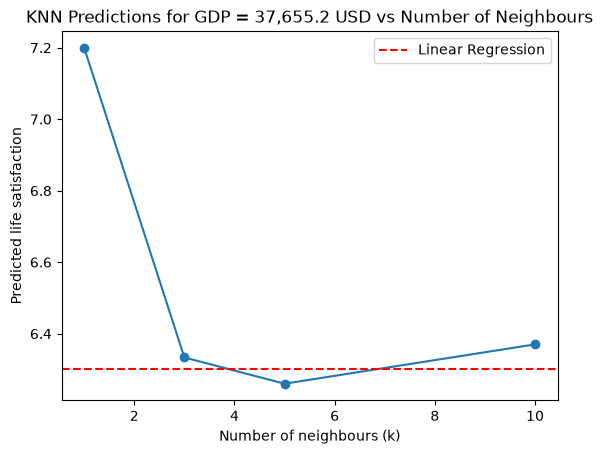

In [72]:
k_values = [1, 3, 5, 10]
predictions = []
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X, Y)
    pred = np.ravel(model.predict(X_new))[0]
    predictions.append(pred)
    print(f"k = {k:2d} -> predicted life satisfaction = {pred:.2f}")

pyplot.plot(k_values, predictions, marker="o")
pyplot.axhline(lin_pred, color="red", linestyle="--", label="Linear Regression")
pyplot.xlabel("Number of neighbours (k)")
pyplot.ylabel("Predicted life satisfaction")
pyplot.title("KNN Predictions for GDP = 37,655.2 USD vs Number of Neighbours")
pyplot.legend(); pyplot.show()